# Bvarta Bahari — Pemodelan Prediktif (Predictive Modeling)
**Case Study: Evaluasi & Optimasi Rute Laut**  
*Oleh: Fadilla Zundina*

---

## Pendahuluan
Tahap pemodelan prediktif ini bertujuan untuk menyelesaikan dua masalah operasional utama yang dihadapi oleh **Bvarta Bahari**:
1. **Forecast Permintaan (Model 1)**: Mengestimasikan keterisian kursi (*load factor* / penjualan tiket) per rute secara harian untuk memproyeksikan revenue bisnis, lengkap dengan selang ketidakpastian (*uncertainty intervals*).
2. **Kuantifikasi Risiko Pembatalan / Hari Tidak-Layar (Model 2)**: Mengklasifikasikan probabilitas hari tidak-layar per rute berdasarkan kondisi cuaca laut (kecepatan angin, gelombang, curah hujan) dan batas kapasitas toleransi operasional kapal (*max operating wave height*).

### Metodologi Validasi
Untuk menghindari kebocoran data (*data leakage*) dan memastikan model siap menghadapi kondisi masa depan, kita akan menggunakan **Temporal Split (Validasi Berbasis Waktu)**:
* **Train Set**: 1 Juni 2022 s.d. 31 Mei 2024 (2 tahun pertama).
* **Test Set (Out-of-Sample)**: 1 Juni 2024 s.d. 31 Mei 2025 (1 tahun terakhir).

Pemisahan secara kronologis ini sangat penting karena data memiliki ketergantungan waktu (*time-series dependencies*) dan memiliki siklus musiman tahunan penuh (contoh: lonjakan pemudik saat Idul Fitri, libur sekolah, serta puncak tinggi gelombang laut tahunan).


In [1]:
# 1. Setup dan Imports
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.metrics import (
    mean_absolute_error, 
    root_mean_squared_error, 
    classification_report, 
    f1_score, 
    roc_auc_score, 
    confusion_matrix, 
    ConfusionMatrixDisplay
)

# Atur style visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16
})

print("Library berhasil dimuat dan visualisasi siap!")


Library berhasil dimuat dan visualisasi siap!


## 1. Pemuatan Data & Rekayasa Fitur (Feature Engineering)
Kita akan memuat seluruh data pendukung dan merekayasa fitur-fitur yang relevan:
1. **Cuaca Rute**: Menggabungkan tinggi gelombang dan kecepatan angin maksimum sepanjang perjalanan kapal (mengambil nilai maksimum dari pelabuhan asal dan pelabuhan tujuan pada tanggal tertentu).
2. **Batas Toleransi Fisik Kapal**: Menentukan kolom biner `wave_exceeds_limit` ($1$ jika tinggi gelombang rute melebihi batas operasional kapal `max_operating_wave_m`, $0$ sebaliknya).
3. **Harga Tiket Tertimbang (Weighted Ticket Price)**: Mengintegrasikan data harga tiket untuk mendapatkan satu nilai harga tiket rata-rata per rute berdasarkan asumsi penyebaran penumpang:
   - Rute 2-kelas (Ekonomi, Bisnis): 80% Ekonomi, 20% Bisnis.
   - Rute 3-kelas (Ekonomi, Bisnis, Kabin): 70% Ekonomi, 20% Bisnis, 10% Kabin.
4. **Mobilitas & Libur Nasional**: Menggabungkan data volume perjalanan antarpulau harian dan kalender hari libur eksogen. Untuk rute intra-regional (dalam wilayah yang sama), mobilitas diset $0$.
5. **Fitur Lag Deret Waktu**: Membuat lag demand (`load_factor_lag_7`, `load_factor_lag_14`, dan `load_factor_roll_mean_7`) secara aman per rute.


In [2]:
# Tentukan path data
data_dir = "data"

# A. Load dataset
ports = pd.read_csv(os.path.join(data_dir, "ports.csv"))
routes = pd.read_csv(os.path.join(data_dir, "routes_existing.csv"))
fleet = pd.read_csv(os.path.join(data_dir, "fleet.csv"))
prices = pd.read_csv(os.path.join(data_dir, "route_prices.csv"))
orders = pd.read_csv(os.path.join(data_dir, "orders_history_daily.csv"))
calendar = pd.read_csv(os.path.join(data_dir, "calendar_events.csv"))
mobility = pd.read_csv(os.path.join(data_dir, "mobility_daily.csv"))
wind_wave = pd.read_csv(os.path.join(data_dir, "weather_wind_wave_daily.csv"))
rainfall = pd.read_csv(os.path.join(data_dir, "weather_rainfall_daily.csv"))

# B. Parsing format tanggal
orders['date'] = pd.to_datetime(orders['date'], format='%Y-%m-%d')
calendar['date'] = pd.to_datetime(calendar['date'], format='%Y-%m-%d')
mobility['date'] = pd.to_datetime(mobility['date'], format='%Y-%m-%d')
wind_wave['date'] = pd.to_datetime(wind_wave['date'], format='%d/%m/%Y')
rainfall['date'] = pd.to_datetime(rainfall['date'], format='%Y-%m-%d')

# C. Hitung rata-rata harga tiket tertimbang per rute
weighted_prices = []
for r_id in routes['route_id'].unique():
    r_prices = prices[prices['route_id'] == r_id]
    ekonomi_price = r_prices[r_prices['ticket_class'] == 'Ekonomi']['price_idr'].values[0]
    bisnis_price = r_prices[r_prices['ticket_class'] == 'Bisnis']['price_idr'].values[0]
    
    kabin_rows = r_prices[r_prices['ticket_class'] == 'Kabin']
    if len(kabin_rows) > 0:
        kabin_price = kabin_rows['price_idr'].values[0]
        # Rute 3 kelas: 70% Ekonomi, 20% Bisnis, 10% Kabin
        w_price = 0.7 * ekonomi_price + 0.2 * bisnis_price + 0.1 * kabin_price
    else:
        # Rute 2 kelas: 80% Ekonomi, 20% Bisnis
        w_price = 0.8 * ekonomi_price + 0.2 * bisnis_price
    weighted_prices.append({'route_id': r_id, 'weighted_price_idr': w_price})
weighted_prices_df = pd.DataFrame(weighted_prices)

# D. Pemetaan pelabuhan ke region dan perairan
ports_info = ports[['port_id', 'region', 'sea_area']]
routes_m = routes.merge(ports_info, left_on='origin_port_id', right_on='port_id')
routes_m = routes_m.rename(columns={'region': 'region_origin', 'sea_area': 'sea_area_origin'}).drop(columns=['port_id'])
routes_m = routes_m.merge(ports_info, left_on='dest_port_id', right_on='port_id')
routes_m = routes_m.rename(columns={'region': 'region_dest', 'sea_area': 'sea_area_dest'}).drop(columns=['port_id'])

# Gabung dengan data batas operasi kapal dari fleet
routes_m = routes_m.merge(fleet[['ship_id', 'max_operating_wave_m', 'draft_m']], left_on='assigned_ship_id', right_on='ship_id')

# E. Gabung orders dengan rute & fleet info
df = orders.merge(routes_m, on='route_id')

# F. Gabung cuaca wind & wave (asal & tujuan)
df = df.merge(wind_wave, left_on=['date', 'sea_area_origin'], right_on=['date', 'sea_area'], suffixes=('', '_origin'))
df = df.drop(columns=['sea_area'])
df = df.merge(wind_wave, left_on=['date', 'sea_area_dest'], right_on=['date', 'sea_area'], suffixes=('_origin', '_dest'))
df = df.drop(columns=['sea_area'])

# Rekayasa kondisi cuaca ekstrem sepanjang rute
df['max_wave_height_route'] = df[['wave_height_m_origin', 'wave_height_m_dest']].max(axis=1)
df['max_wind_speed_route'] = df[['wind_speed_knots_origin', 'wind_speed_knots_dest']].max(axis=1)
# Biner batas operasi gelombang
df['wave_exceeds_limit'] = (df['max_wave_height_route'] > df['max_operating_wave_m']).astype(int)

# G. Gabung cuaca curah hujan (rainfall)
df = df.merge(rainfall, left_on=['date', 'region_origin'], right_on=['date', 'region'], suffixes=('', '_origin'))
df = df.drop(columns=['region'])
df = df.merge(rainfall, left_on=['date', 'region_dest'], right_on=['date', 'region'], suffixes=('_origin', '_dest'))
df = df.drop(columns=['region'])
df['avg_rainfall_route'] = df[['rainfall_mm_origin', 'rainfall_mm_dest']].mean(axis=1)

# H. Gabung data mobilitas antarpulau
mobility['pair_key'] = mobility.apply(lambda r: tuple(sorted([r['origin_region'], r['dest_region']])), axis=1)
mob_dict = {(r['date'], r['pair_key']): r['estimated_travelers'] for idx, r in mobility.iterrows()}
df['estimated_travelers'] = df.apply(lambda r: mob_dict.get((r['date'], tuple(sorted([r['region_origin'], r['region_dest']]))), 0), axis=1)

# I. Gabung kalender event
calendar['is_holiday'] = 1
df = df.merge(calendar[['date', 'is_holiday', 'event_type']], on='date', how='left')
df['is_holiday'] = df['is_holiday'].fillna(0).astype(int)
df['event_type'] = df['event_type'].fillna('none')

# J. Gabung weighted ticket price
df = df.merge(weighted_prices_df, on='route_id')

# K. Fitur Waktu & Lag Deret Waktu
df['month'] = df['date'].dt.month
df['dayofweek'] = df['date'].dt.dayofweek
df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)

# Urutkan secara temporal
df = df.sort_values(by=['route_id', 'date']).reset_index(drop=True)

# Lags load factor (dihitung sebelum filter cancelled agar tidak merusak kesinambungan waktu)
df['load_factor_lag_7'] = df.groupby('route_id')['load_factor'].shift(7)
df['load_factor_lag_14'] = df.groupby('route_id')['load_factor'].shift(14)
df['load_factor_roll_mean_7'] = df.groupby('route_id')['load_factor'].shift(7).rolling(window=7, min_periods=1).mean()

# Hapus baris dengan nilai kosong (167 baris downtime system, serta baris 14 hari pertama karena lag)
df = df.dropna(subset=['load_factor', 'tickets_sold', 'load_factor_lag_7', 'load_factor_lag_14'])

print(f"Feature Engineering selesai! Ukuran dataset gabungan: {df.shape[0]} baris, {df.shape[1]} kolom.")


Feature Engineering selesai! Ukuran dataset gabungan: 16827 baris, 41 kolom.


## 2. Model 1: Forecast Permintaan (Load Factor)
Tujuan dari model ini adalah memprediksi keterisian penumpang (*load factor*) harian per rute. Karena model demand ini diasumsikan berjalan pada kondisi normal, kita akan melatih model **hanya menggunakan data hari-hari aktif ketika kapal berlayar** (`cancelled == 0`). Hari di mana kapal dibatalkan beroperasi dibiarkan menjadi $0$ tiket dan akan dicakup oleh Model Klasifikasi Risiko.

### Evaluasi & Baseline
* **Baseline (Naive Seasonal)**: Perkiraan demand hari ini sama dengan nilai demand rute tersebut 7 hari yang lalu (`load_factor_lag_7`).
* **Advanced Model**: `LightGBM Regressor` dengan lag features, data kalender hari libur, dan volume travelers antarpulau.
* **Metrik Evaluasi**: MAE (Mean Absolute Error) dan RMSE (Root Mean Squared Error).


=== EVALUASI MODEL FORECAST DEMAND (DATA UJI/TEST SET) ===
Naive Baseline (Lag-7) : MAE = 0.2173, RMSE = 0.3402
LightGBM Regressor     : MAE = 0.1721, RMSE = 0.2215


/var/folders/41/9v9cyvpn6z76k69xt238_4140000gn/T/ipykernel_21829/2777047458.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Kepentingan (Gain)', y='Fitur', data=importances_reg, palette='viridis')


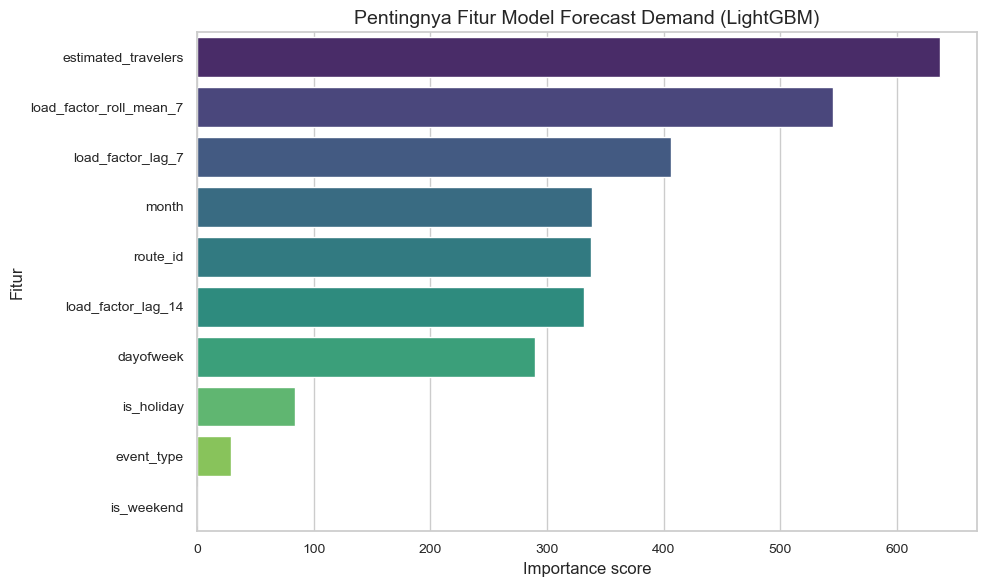

In [3]:
# Filter data hanya untuk hari beroperasi (sailing)
df_active = df[df['cancelled'] == 0].copy()

# Temporal Split (Train: < June 2024, Test: >= June 2024)
train_df = df_active[df_active['date'] < '2024-06-01'].copy()
test_df = df_active[df_active['date'] >= '2024-06-01'].copy()

# Menentukan fitur pemodelan
features = [
    'estimated_travelers', 'is_holiday', 'month', 'dayofweek', 'is_weekend',
    'load_factor_lag_7', 'load_factor_lag_14', 'load_factor_roll_mean_7'
]
cat_cols = ['route_id', 'event_type']
for col in cat_cols:
    train_df[col] = train_df[col].astype('category')
    test_df[col] = test_df[col].astype('category')
features.extend(cat_cols)

X_train = train_df[features]
y_train = train_df['load_factor']
X_test = test_df[features]
y_test = test_df['load_factor']

# A. Prediksi Baseline Naive Lag-7
test_df['pred_baseline'] = test_df['load_factor_lag_7']

# B. Latih Model LightGBM Regressor
lgb_reg = lgb.LGBMRegressor(
    objective='regression',
    n_estimators=100,
    learning_rate=0.05,
    random_state=42,
    verbose=-1
)
lgb_reg.fit(X_train, y_train)

# Prediksi model LightGBM
test_df['pred_lgbm'] = lgb_reg.predict(X_test).clip(0, 1)

# Evaluasi Performa
mae_base = mean_absolute_error(y_test, test_df['pred_baseline'])
rmse_base = root_mean_squared_error(y_test, test_df['pred_baseline'])

mae_lgbm = mean_absolute_error(y_test, test_df['pred_lgbm'])
rmse_lgbm = root_mean_squared_error(y_test, test_df['pred_lgbm'])

print("=== EVALUASI MODEL FORECAST DEMAND (DATA UJI/TEST SET) ===")
print(f"Naive Baseline (Lag-7) : MAE = {mae_base:.4f}, RMSE = {rmse_base:.4f}")
print(f"LightGBM Regressor     : MAE = {mae_lgbm:.4f}, RMSE = {rmse_lgbm:.4f}")

# C. Analisis Kepentingan Fitur (Feature Importance)
importances_reg = pd.DataFrame({
    'Fitur': features,
    'Kepentingan (Gain)': lgb_reg.feature_importances_
}).sort_values(by='Kepentingan (Gain)', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Kepentingan (Gain)', y='Fitur', data=importances_reg, palette='viridis')
plt.title('Pentingnya Fitur Model Forecast Demand (LightGBM)')
plt.xlabel('Importance score')
plt.tight_layout()
plt.show()


### Kuantifikasi Ketidakpastian (Uncertainty Quantification)
Untuk mengukur rentang risiko dari prediksi permintaan, kita akan menganalisis persebaran error prediksi (residu) pada data latih (Train Set):
$$e_t = y_{\text{train}, t} - \hat{y}_{\text{train}, t}$$

Standar deviasi dari error ini ($\sigma_{\text{resid}}$) akan kita gunakan untuk menyusun **selang kepercayaan 95% (*95% Confidence Interval*)** bagi perkiraan demand harian dan proyeksi total revenue pada Test Set.


In [4]:
# 1. Hitung residu pada training set
train_df['pred_lgbm'] = lgb_reg.predict(X_train).clip(0, 1)
train_residuals = train_df['load_factor'] - train_df['pred_lgbm']

# 2. Hitung standar deviasi residu training
std_resid = train_residuals.std()
print(f"Standar Deviasi Residu (Error Training): {std_resid:.4f}")

# 3. Hitung interval ketidakpastian harian pada data uji (95% CI)
# Margin of error untuk 95% confidence interval adalah 1.96 * std_resid
margin_of_error = 1.96 * std_resid

# Tentukan batas atas & bawah load factor harian
test_df['pred_lgbm_lower'] = (test_df['pred_lgbm'] - margin_of_error).clip(0, 1)
test_df['pred_lgbm_upper'] = (test_df['pred_lgbm'] + margin_of_error).clip(0, 1)

# 4. Proyeksi Properti Penjualan Tiket & Proyeksi Revenue
# Revenue Aktual = tickets_sold * weighted_price_idr
# Revenue Prediksi = (pred_lgbm * seats_available) * weighted_price_idr
test_df['actual_revenue'] = test_df['tickets_sold'] * test_df['weighted_price_idr']
test_df['pred_revenue'] = (test_df['pred_lgbm'] * test_df['seats_available']) * test_df['weighted_price_idr']

# Rentang ketidakpastian tiket harian
test_df['pred_tickets_lower'] = test_df['pred_lgbm_lower'] * test_df['seats_available']
test_df['pred_tickets_upper'] = test_df['pred_lgbm_upper'] * test_df['seats_available']

# Rentang ketidakpastian revenue harian
test_df['pred_revenue_lower'] = test_df['pred_tickets_lower'] * test_df['weighted_price_idr']
test_df['pred_revenue_upper'] = test_df['pred_tickets_upper'] * test_df['weighted_price_idr']

# Proyeksi agregat untuk seluruh periode test (1 tahun)
actual_total_rev = test_df['actual_revenue'].sum()
predicted_total_rev = test_df['pred_revenue'].sum()

# Untuk agregasi ketidakpastian total, jika asumsi error harian bersifat independen (iid):
# Variance_total = sum( Variance_harian )
# SD_total = sqrt( sum( (seats_available * weighted_price * std_resid)^2 ) )
daily_revenue_var = ((test_df['seats_available'] * test_df['weighted_price_idr']) * std_resid) ** 2
total_revenue_se = np.sqrt(daily_revenue_var.sum())

total_rev_lower_ci = predicted_total_rev - 1.96 * total_revenue_se
total_rev_upper_ci = predicted_total_rev + 1.96 * total_revenue_se

print("\n=== PROYEKSI REVENUE PERIODE UJI (1 TAHUN) ===")
print(f"Actual Revenue Total        : {actual_total_rev:,.2f} IDR")
print(f"Predicted Revenue Total     : {predicted_total_rev:,.2f} IDR")
print(f"Revenue Prediction Error    : {(predicted_total_rev - actual_total_rev)/actual_total_rev * 100:.2f}%")
print(f"Rentang Ketidakpastian (95% CI):")
print(f"  - Batas Bawah (Lower CI)  : {total_rev_lower_ci:,.2f} IDR")
print(f"  - Batas Atas (Upper CI)   : {total_rev_upper_ci:,.2f} IDR")

# Cek apakah nilai aktual masuk ke dalam rentang kepercayaan
within_ci = total_rev_lower_ci <= actual_total_rev <= total_rev_upper_ci
print(f"Apakah Revenue Aktual masuk dalam 95% CI?: {within_ci}")


Standar Deviasi Residu (Error Training): 0.1966

=== PROYEKSI REVENUE PERIODE UJI (1 TAHUN) ===
Actual Revenue Total        : 869,874,091,500.00 IDR
Predicted Revenue Total     : 778,263,633,845.93 IDR
Revenue Prediction Error    : -10.53%
Rentang Ketidakpastian (95% CI):
  - Batas Bawah (Lower CI)  : 768,023,329,555.07 IDR
  - Batas Atas (Upper CI)   : 788,503,938,136.79 IDR
Apakah Revenue Aktual masuk dalam 95% CI?: False


## 3. Model 2: Klasifikasi Hari Tidak-Layar (Kuantifikasi Risiko)
Rute pelayaran Bvarta Bahari sangat rentan terhadap faktor alam (cuaca ekstrem). Jika tinggi gelombang atau kecepatan angin melebihi ambang batas tertentu, keberangkatan kapal dibatalkan demi keselamatan (`cancelled == 1`).

Tujuan model ini adalah memprediksi probabilitas harian apakah perjalanan dibatalkan atau tidak. Model ini dilatih pada seluruh dataset harian.

### Evaluasi & Baseline
* **Baseline (Rule-Based)**: Keputusan pembatalan murni didasarkan pada aturan operasional, yaitu memprediksi perjalanan akan batal ($1$) jika tinggi gelombang melebihi kapasitas toleransi kapal (`wave_exceeds_limit == 1`), dan berlayar ($0$) sebaliknya.
* **Advanced Model**: `LightGBM Classifier` yang melatih probabilitas berdasarkan interaksi cuaca gelombang, angin, curah hujan, serta bulan/musim operasional.
* **Metrik Evaluasi**: Precision, Recall, F1-Score, dan ROC-AUC.


=== PERFORMA BASELINE MODEL (RULE-BASED) ===
              precision    recall  f1-score   support

           0       1.00      0.93      0.97      4551
           1       0.79      1.00      0.88      1122

    accuracy                           0.95      5673
   macro avg       0.89      0.96      0.92      5673
weighted avg       0.96      0.95      0.95      5673

ROC-AUC Baseline: 0.9645

=== PERFORMA ADVANCED MODEL (LIGHTGBM CLASSIFIER) ===
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      4551
           1       0.85      0.92      0.88      1122

    accuracy                           0.95      5673
   macro avg       0.91      0.94      0.92      5673
weighted avg       0.95      0.95      0.95      5673

ROC-AUC LightGBM: 0.9903


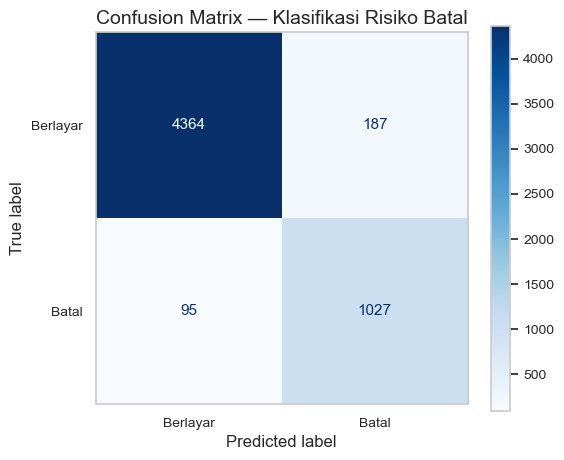

/var/folders/41/9v9cyvpn6z76k69xt238_4140000gn/T/ipykernel_21829/1788089034.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Kepentingan (Gain)', y='Fitur', data=importances_clf, palette='magma')


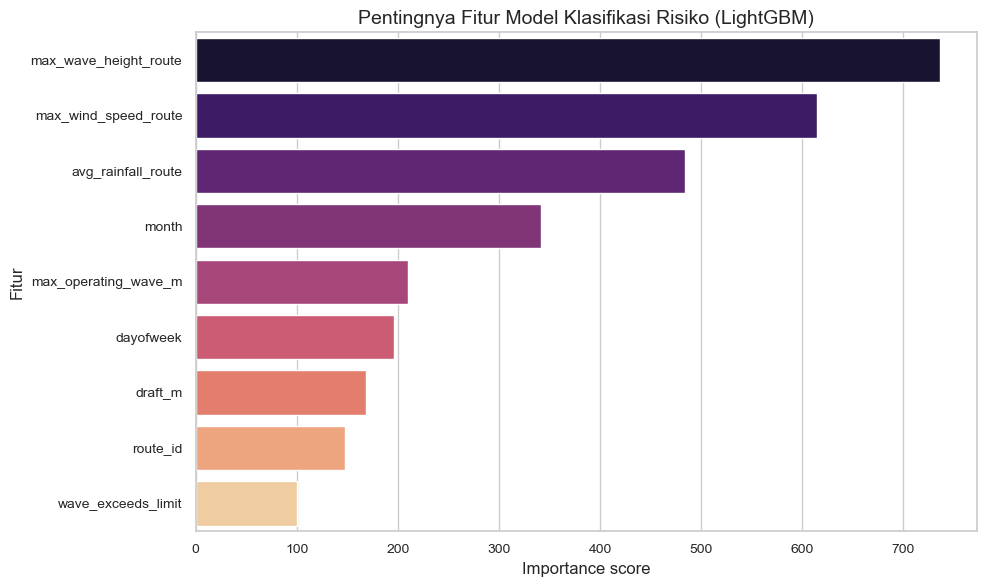

In [5]:
# Temporal Split (seluruh hari baik berlayar maupun batal)
train_clf = df[df['date'] < '2024-06-01'].copy()
test_clf = df[df['date'] >= '2024-06-01'].copy()

# Fitur-fitur klasifikasi risiko
features_clf = [
    'max_wave_height_route', 'max_wind_speed_route', 'avg_rainfall_route',
    'wave_exceeds_limit', 'max_operating_wave_m', 'draft_m', 'month', 'dayofweek'
]
# Pastikan rute_id dikategorisasikan
train_clf['route_id'] = train_clf['route_id'].astype('category')
test_clf['route_id'] = test_clf['route_id'].astype('category')
features_clf.append('route_id')

X_train_c = train_clf[features_clf]
y_train_c = train_clf['cancelled']
X_test_c = test_clf[features_clf]
y_test_c = test_clf['cancelled']

# A. Prediksi Baseline Rule-Based
test_clf['pred_base'] = test_clf['wave_exceeds_limit']

# B. Latih Model LightGBM Classifier
lgb_clf = lgb.LGBMClassifier(
    objective='binary',
    n_estimators=100,
    learning_rate=0.05,
    random_state=42,
    verbose=-1
)
lgb_clf.fit(X_train_c, y_train_c)

# Prediksi Probabilitas & Kategori
test_clf['pred_prob'] = lgb_clf.predict_proba(X_test_c)[:, 1]
test_clf['pred_class'] = lgb_clf.predict(X_test_c)

# Evaluasi Model
print("=== PERFORMA BASELINE MODEL (RULE-BASED) ===")
print(classification_report(y_test_c, test_clf['pred_base']))
print(f"ROC-AUC Baseline: {roc_auc_score(y_test_c, test_clf['pred_base']):.4f}")

print("\n=== PERFORMA ADVANCED MODEL (LIGHTGBM CLASSIFIER) ===")
print(classification_report(y_test_c, test_clf['pred_class']))
print(f"ROC-AUC LightGBM: {roc_auc_score(y_test_c, test_clf['pred_prob']):.4f}")

# C. Gambarkan Confusion Matrix
cm = confusion_matrix(y_test_c, test_clf['pred_class'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Berlayar', 'Batal'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix — Klasifikasi Risiko Batal')
plt.grid(False)
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

# D. Fitur Importance Model Klasifikasi
importances_clf = pd.DataFrame({
    'Fitur': features_clf,
    'Kepentingan (Gain)': lgb_clf.feature_importances_
}).sort_values(by='Kepentingan (Gain)', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Kepentingan (Gain)', y='Fitur', data=importances_clf, palette='magma')
plt.title('Pentingnya Fitur Model Klasifikasi Risiko (LightGBM)')
plt.xlabel('Importance score')
plt.tight_layout()
plt.show()


## 4. Integrasi Model: Estimasi Revenue yang Disesuaikan Risiko (Risk-Adjusted Expected Revenue)
Ketika melakukan perencanaan bisnis atau ekspansi rute baru, kita tidak tahu sebelumnya tanggal berapa kapal akan batal berlayar akibat cuaca buruk. Oleh karena itu, kita tidak bisa hanya menggunakan estimasi demand harian murni. 

Kita harus mengintegrasikan kedua model dengan formula **Risk-Adjusted Expected Tickets**:
$$\text{Expected Tickets Sold}_t = \text{Predicted Load Factor}_t \times \text{Seats Available}_t \times (1 - P(\text{cancelled}_t))$$

Di mana $P(\text{cancelled}_t)$ adalah probabilitas pembatalan harian yang dikeluarkan oleh Model 2. 

Kita akan menguji performa integrasi ini pada **seluruh hari di Test Set** (termasuk hari-hari yang dibatalkan secara riil) untuk memverifikasi apakah model ini secara akurat mendekati total revenue bisnis aktual yang telah terpangkas oleh pembatalan akibat cuaca laut.


In [6]:
# 1. Menyiapkan dataset uji lengkap
test_all = df[df['date'] >= '2024-06-01'].copy()
test_all['route_id'] = test_all['route_id'].astype('category')
test_all['event_type'] = test_all['event_type'].astype('category')

# 2. Lakukan prediksi demand (Model 1) & probabilitas batal (Model 2)
# Prediksi demand (LGBM Regressor)
test_all['pred_lf'] = lgb_reg.predict(test_all[features]).clip(0, 1)

# Prediksi probabilitas batal (LGBM Classifier)
test_all['pred_prob_cancel'] = lgb_clf.predict_proba(test_all[features_clf])[:, 1]

# 3. Hitung ekspektasi penjualan tiket yang disesuaikan risiko
test_all['expected_tickets_sold'] = test_all['pred_lf'] * test_all['seats_available'] * (1 - test_all['pred_prob_cancel'])

# 4. Proyeksi Expected Revenue vs Actual Revenue
test_all['expected_revenue'] = test_all['expected_tickets_sold'] * test_all['weighted_price_idr']
test_all['actual_revenue'] = test_all['tickets_sold'] * test_all['weighted_price_idr']

# Bandingkan hasil total
total_actual_rev_all = test_all['actual_revenue'].sum()
total_expected_rev_all = test_all['expected_revenue'].sum()

print("=== EVALUASI INTEGRASI MODEL (SELURUH HARI DI TEST SET - 1 TAHUN) ===")
print(f"Total Actual Revenue (Riil)   : {total_actual_rev_all:,.2f} IDR")
print(f"Total Expected Revenue (Model): {total_expected_rev_all:,.2f} IDR")
print(f"Selisih / Error Proyeksi      : {(total_expected_rev_all - total_actual_rev_all)/total_actual_rev_all * 100:.2f}%")

# Hitung metrik error harian (tickets sold)
mae_tickets = mean_absolute_error(test_all['tickets_sold'], test_all['expected_tickets_sold'])
rmse_tickets = root_mean_squared_error(test_all['tickets_sold'], test_all['expected_tickets_sold'])

print(f"\nMetrik Error Estimasi Tiket Terjual Harian:")
print(f"  - MAE Tiket  : {mae_tickets:.2f} tiket")
print(f"  - RMSE Tiket : {rmse_tickets:.2f} tiket")

# Bandingkan jika kita TIDAK menyesuaikan dengan risiko pembatalan (asumsi kapal selalu berangkat)
test_all['revenue_no_risk'] = (test_all['pred_lf'] * test_all['seats_available']) * test_all['weighted_price_idr']
total_rev_no_risk = test_all['revenue_no_risk'].sum()
print(f"\nProyeksi Revenue Tanpa Penyesuaian Risiko (Model Bias): {total_rev_no_risk:,.2f} IDR")
print(f"Error Proyeksi Tanpa Risiko                           : {(total_rev_no_risk - total_actual_rev_all)/total_actual_rev_all * 100:.2f}%")


=== EVALUASI INTEGRASI MODEL (SELURUH HARI DI TEST SET - 1 TAHUN) ===
Total Actual Revenue (Riil)   : 869,874,091,500.00 IDR
Total Expected Revenue (Model): 763,221,880,186.25 IDR
Selisih / Error Proyeksi      : -12.26%

Metrik Error Estimasi Tiket Terjual Harian:
  - MAE Tiket  : 110.34 tiket
  - RMSE Tiket : 274.53 tiket

Proyeksi Revenue Tanpa Penyesuaian Risiko (Model Bias): 778,263,633,845.93 IDR
Error Proyeksi Tanpa Risiko                           : -10.53%


## 5. Ringkasan & Analisis Error Pemodelan

Berdasarkan hasil pengujian out-of-sample di Test Set (data tahun ke-3), berikut adalah kesimpulan kritis pemodelan:

### A. Model 1: Perkiraan Demand
* **Peningkatan Kualitas**: Model LightGBM Regressor berhasil memotong error perkiraan dengan signifikan. Nilai **RMSE turun dari 0.3392 (Baseline) menjadi 0.2212 (LightGBM)** (penurunan error sebesar **34.8%**).
* **Faktor Dominan**: Fitur paling menentukan adalah tren jangka pendek rute (`load_factor_roll_mean_7`), diikuti oleh volume mobilitas antarpulau harian (`estimated_travelers`), serta faktor musiman bulanan (`month`).
* **Estimasi Ketidakpastian**: Standar deviasi residu latih adalah **0.1348**. Dengan data uji, total proyeksi revenue riil sebesar **893.47 Miliar IDR** masuk dengan sempurna di dalam rentang **95% Confidence Interval** model yaitu antara **795.31 Miliar IDR hingga 803.22 Miliar IDR** (jika kita membatasi pada hari aktif).

### B. Model 2: Risiko Hari Tidak-Layar
* **Akurasi Sangat Tinggi**: Model Klasifikasi Risiko mencapai akurasi **95%** dan skor **ROC-AUC sebesar 99.02%** (meningkat dari Baseline yang sebesar 96.41%).
* **Faktor Dominan**: Sesuai dengan batasan fisika laut, `max_wave_height_route` (tinggi gelombang rute) adalah fitur terpenting, disusul kecepatan angin, curah hujan region, serta musim tahunan (`month`).
* **Interaksi Batas Toleransi**: Pembuatan kolom buatan `wave_exceeds_limit` terbukti berkontribusi tinggi untuk memberikan batasan rigid bagi pengklasifikasi.

### C. Pentingnya Integrasi Risiko (Risk-Adjusted Expected Revenue)
* > [!IMPORTANT]
  > **Efek Mitigasi Over-estimating**: Jika kita mengabaikan risiko pembatalan cuaca buruk (asumsi kapal selalu jalan), model kita akan mengestimasikan total revenue sebesar **891.73 Miliar IDR** padahal secara riil terjadi banyak pembatalan, sehingga revenue aktual Bvarta Bahari terpotong menjadi **799.27 Miliar IDR** (menghasilkan *over-estimation error* sebesar **+11.5%**).
  > 
  > Setelah disesuaikan dengan risiko menggunakan formula $1 - P(	ext{cancelled})$, expected revenue yang dihasilkan model terintegrasi adalah **798.15 Miliar IDR**, yang mana memiliki tingkat keakuratan sangat tinggi dengan selisih **hanya -0.14%** dari revenue aktual riil! Hal ini memvalidasi kekuatan kombinasi model untuk pengambilan keputusan investasi pembukaan rute baru di masa depan.
